In [1]:
## Standard libraries ====
import os
import random
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

## Visualization ====
import logomaker
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

## PyTorch and Machine learning ====
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

## Utilities ====
from util import getPFM, Motif2Seqs, sci_ticks

In [2]:
## Set random seed for reproducibility
def set_seed(seed):
    """Set seed for reproducibility across libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # If using GPUs:
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For deterministic operations (optional, can slow things down):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Set seed
SEED = 777
set_seed(SEED)

## Determine if a GPU is available and select the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## TensorBoard setup instructions (can be uncommented in a notebook)
%load_ext tensorboard
%tensorboard --logdir=runs --port=5678

Using device: cuda


In [3]:
def stratified_sample(df, col, counts, seed=SEED):
    """
    Performs stratified sampling by extracting a specified number of samples from each bin of a column in the dataframe.
    The column is divided into bins, and a defined number of samples is taken from each bin.

    Args:
        df (pd.DataFrame): The input dataframe.
        col (str): The column used for creating bins, which serves as the basis for stratification.
        counts (list): Number of samples to extract from each bin, corresponding to each created bin.
        seed (int): Random seed for reproducibility.

    Returns:
        pd.DataFrame: Dataframe containing the extracted stratified samples.
    """
    np.random.seed(seed)
    df['grp'] = pd.cut(df[col], bins=len(counts))
    extracted = pd.concat(
        df[df['grp'] == grp].sample(cnt, replace=True, random_state=seed)
        for grp, cnt in zip(sorted(df['grp'].unique()), counts)
        )
    return extracted.drop(columns=['grp'])

In [4]:
def dna_one_hot(seq, flatten=False):
    """
    Convert a DNA sequence to its one-hot encoded binary representation.

    Parameters:
        seq (str): The DNA sequence to convert, consisting of characters 'A', 'C', 'G', 'T', or '-'.
        flatten (bool): Whether to return the array in a flattened form (default is False).
    
    Returns:
        np.ndarray: A numpy array of one-hot encoded binary arrays representing the DNA sequence.
                    Each base is represented by a binary array of length 4, where only one element is 1 (indicating the base) and all others are 0.
                    The character '-' is represented by an array of all zeros. If flatten is True, the array will be flattened to a 1D array.
    """
    mapping = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1], '-': [0, 0, 0, 0], 'N': [1/4, 1/4, 1/4, 1/4]}
    one_hot = np.array([mapping.get(base, [0, 0, 0, 0]) for base in seq.upper()]).T
    return one_hot.flatten() if flatten else one_hot

In [5]:
## Data Sampling
## ========================================
def PpurR(seq):
    # return 'TTCGTCTTCACACAGCAGCAGTCAGGTACTCCAGTCCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACTAAATCTATGTAGCTGTCACC' # 100 bp
    return 'CACAGCAGCAGTCAGGTACTCCAGTCCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACTAAATCTATGT' # 80 bp

def SL16(seq):
    # return 'TCGTCTTCACACAGCAGCAGTCAGGTACTCCAGTAAATGCTTGACT'+seq+'TATTATGCACACCCCTAAATCTATGTAGCTGTCACCGG' # 100 bp
    return 'ACAGCAGCAGTCAGGTACTCCAGTAAATGCTTGACT'+seq+'TATTATGCACACCCCTAAATCTATGTAG' # 80 bp

def SL17(seq):
    # return 'TTCGTCTTCACACAGCAGCAGTCAGGTACTCCAGTCCACTTGACC'+seq+'TAACCTTCCACGCTTACTAAATCTATGTAGCTGTCACC' # 100 bp
    return 'CACAGCAGCAGTCAGGTACTCCAGTCCACTTGACC'+seq+'TAACCTTCCACGCTTACTAAATCTATGT' # 80 bp

def SL18(seq):
    # return 'GGCCCTTTCGTCTTCACACAGCAGCTCAGGTACTCAGGCTTTACA'+seq+'GATAATGTGTGGAATTAAATCTATGTAGCTGTCACCG' # 100 bp
    return 'TCTTCACACAGCAGCTCAGGTACTCAGGCTTTACA'+seq+'GATAATGTGTGGAATTAAATCTATGTA' # 80 bp

def DL(seq):
    # return 'GTCTTCACACAGCAGCAGTCAGGTACTCCAGTAAATGCTTGCCCGCCGCGTGATTCGTGTTATAAC'+seq+'CAAAATCTATGTAGCTGTCACCGGAT' # 100 bp
    return 'AGCAGCAGTCAGGTACTCCAGTAAATGCTTGCCCGCCGCGTGATTCGTGTTATAAC'+seq+'CAAAATCTATGTAGCT' # 80 bp

def UL(seq):
    # return 'ACAGGGCAGGCAGAAAAAG'+seq+'GGCTTGCGGCTTTTGCCGCTTTTTTTTACCCTGCACACCCCTAAATCTATGTAGCTGTCACC' # 100 bp
    return 'CAGAAAAAG'+seq+'GGCTTGCGGCTTTTGCCGCTTTTTTTTACCCTGCACACCCCTAAATCTATGT' # 80 bp
def ITS(seq):
    # return 'ACAGCAGCAGTCAGGTACTCCAGTCCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACTAAATCTATGTAGCTGTCACC' # 100 bp
    return 'AGCAGCGTTAAATTCACGCCCTTCTCTTGAGACATTTCTTTTGCACTGGTAAACTAAATC'+seq+'GTCCCAGGCT' # 80 bp
    # return 'ACAGCAGNNNNNNNNNNNNNNNNNNNNCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACTAAATCTATGT' # 80 bp
    # return 'ACAGCAGCAGTCAGGTACTCCAGTCCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACT' # 70 bp
    # return 'ACAGCAGNNNNNNNNNNNNNNNNNNNNCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACT' # 70 bp

## ========================================
df_PL17 = stratified_sample(pd.read_pickle("../tables/PL.pkl"), 'LogGFP', [2000, 2000, 2000, 1000, 1000, 1000, 500, 500])[['rep1', 'rep2', 'LogGFP']]
df_PL17['Sequence'] = df_PL17.index.map(PpurR)
df_PL17['Library'] = "PL17"

df_SL16 = stratified_sample(pd.read_pickle("../tables/SL16.pkl"), 'LogGFP', [300]*10)[['rep1', 'rep2', 'LogGFP']]
df_SL16['Sequence'] = df_SL16.index.map(SL16)
df_SL16['Library'] = "SL16"

df_SL17 = stratified_sample(pd.read_pickle("../tables/SL17.pkl"), 'LogGFP', [400]*10)[['rep1', 'rep2', 'LogGFP']]
df_SL17['Sequence'] = df_SL17.index.map(SL17)
df_SL17['Library'] = "SL17"

df_SL18 = stratified_sample(pd.read_pickle("../tables/SL18.pkl"), 'LogGFP', [300]*10)[['rep1', 'rep2', 'LogGFP']]
df_SL18['Sequence'] = df_SL18.index.map(SL18)
df_SL18['Library'] = "SL18"

df_DL = stratified_sample(pd.read_pickle("../tables/DL.pkl"), 'LogGFP', [200]*10)[['rep1', 'rep2', 'LogGFP']]
df_DL['Sequence'] = df_DL.index.map(DL)
df_DL['Library'] = "DL"

df_UL = stratified_sample(pd.read_pickle("../tables/UL.pkl"), 'LogGFP', [1000, 2000, 3000, 3000, 2000, 1000])[['rep1', 'rep2', 'LogGFP']]
df_UL['Sequence'] = df_UL.index.map(UL)
df_UL['Library'] = "UL"


df_ITS = stratified_sample(pd.read_pickle("../tables/ITS.pkl"), 'LogGFP', [1000]*10)[['rep1', 'rep2', 'LogGFP']]
df_ITS['Sequence'] = df_ITS.index.map(ITS)
df_ITS['Library'] = "ITS"

df_train = pd.concat([df_PL17, df_SL16, df_SL17, df_SL18, df_DL, df_UL, df_ITS]).reset_index(drop=True)
df_train

## ========================================
df_ITS = pd.read_pickle("../tables/ITS.pkl")
df_ITS = stratified_sample(df_ITS, 'LogGFP', [1000]*10)[['rep1', 'rep2', 'LogGFP']]
df_ITS['Sequence'] = df_ITS.index
df_ITS['Library'] = "ITS"

df_train = pd.concat([df_ITS]).reset_index(drop=True)
df_train

,rep1,rep2,LogGFP,Sequence,Library
0,0.378247,0.380042,0.379144,TATGGGGGAG,ITS
1,0.206713,0.682815,0.444764,GGGGGTGCAC,ITS
2,0.502132,0.362932,0.432532,CGGGTGACCA,ITS
3,0.289269,0.227785,0.258527,TAGAAGCTCC,ITS
4,0.495520,0.234177,0.364848,ACTCCTTTCT,ITS
...,...,...,...,...,...
9995,2.463734,2.464636,2.464185,CCGGTTAGAG,ITS
9996,2.350883,2.464636,2.407759,TCTCTCGTAA,ITS
9997,2.369131,2.444653,2.406892,CCGATGTTAG,ITS
9998,2.432013,2.440972,2.436493,CTGGTTGTTA,ITS


In [6]:
class DNAFunctionPredictor(nn.Module):
    def __init__(self, seq_length, num_conds):
        super(DNAFunctionPredictor, self).__init__()
        self.seq_length = seq_length
        
        ## Conv1D layer for DNA sequence
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=1, kernel_size=10, stride=1)
        self._initialize_conv1()
        
        # self.conv2 = nn.Conv1d(in_channels=2, out_channels=3, kernel_size=25, stride=1) # 31+2+1
        # self._initialize_conv2()
        
        ## Define custom trainable parameters for self-defined function
        self.param_max = nn.Parameter(torch.tensor(np.log(1000)), requires_grad=True)
        self.param_min = nn.Parameter(torch.tensor(np.log(0.5)), requires_grad=True)
        self.param_e0 = nn.Parameter(torch.tensor(0.0), requires_grad=True)
        
        ## Fully connected layers
        self.fc1 = nn.Linear(num_conds + 1, 8)  # Adjust input size
        self.fc2 = nn.Linear(8, 8)
        self.fc3 = nn.Linear(8, 1)  # Output a single value

    def _initialize_conv1(self):
        # ## Define custom motifs for each filter
        # motif1 = getPFM(Motif2Seqs("TTGACA"), ratios=True).values.T  # Shape: (4, 6)
        # motif2 = getPFM(Motif2Seqs("TATAAT"), ratios=True).values.T  # Shape: (4, 6)
    
        # ## Combine into a single array for one filter
        # filter1_weights = np.concatenate([np.zeros((4, 8)), motif1, np.zeros((4, 8))], axis=1)
        # filter2_weights = np.concatenate([np.zeros((4, 8)), motif2, np.zeros((4, 8))], axis=1)
    
        # ## Stack filters to form the weight tensor (out_channels, in_channels, kernel_size)
        # custom_weights = np.stack([filter1_weights, filter2_weights], axis=0)
    
        ## Assign the custom weights to the layer
        self.conv1.weight.data.zero_()
        self.conv1.weight.requires_grad = True
    
        ## Set the biases to zero
        self.conv1.bias.data.zero_()
        self.conv1.bias.requires_grad = False

    # def _initialize_conv2(self):    
    #     ## Define the weights directly using numpy
    #     filter1_weights = np.zeros((2, 25))
    #     filter2_weights = np.zeros((2, 25))
    #     filter3_weights = np.zeros((2, 25))
        
    #     filter1_weights[0, 0], filter1_weights[1, 24] = 1, 1
    #     filter2_weights[0, 1], filter2_weights[1, 24] = 1, 1
    #     filter3_weights[0, 2], filter3_weights[1, 24] = 1, 1
    
    #     ## Stack filters to form the weight tensor (out_channels, in_channels, kernel_size)
    #     custom_weights = np.stack([filter1_weights, filter2_weights, filter3_weights], axis=0)
    
    #     ## Assign the custom weights to the layer
    #     self.conv2.weight.data = torch.tensor(custom_weights, dtype=torch.float32)
    #     self.conv2.weight.requires_grad = False
    
    #     ## Set the biases to zero
    #     self.conv2.bias.data.zero_()
    #     self.conv2.bias.requires_grad = True
    
    def energy(self, dna_seq):
        """
        Process the DNA sequence through Conv1D and apply global max pooling.
        :param dna_seq: DNA sequence (batch_size, 4, seq_length)
        :return: Processed sequence features (batch_size, 1)
        """
        x = self.conv1(dna_seq)
        # x = self.conv2(x)
        x = x.view(x.size(0), -1)  # Remove the channel dimension
        x = F.max_pool1d(x, kernel_size=x.size(-1))  # Global max pooling
        return x

    def energy2expression(self, x):
        """
        Custom function with Boltzmann weight and logarithmic transformation.
        :param x: Input tensor (batch_size, num_features)
        :return: Transformed tensor based on the custom formula.
        """
        ## Calculate Boltzmann weight
        beta = 1/(0.001987*310) # 1/(kB*T) ~ 1.6234
        BoltzWeight = torch.exp(beta * (x + self.param_e0))
        
        ## Exponentiate trainable parameters for Max and Min
        Max = torch.exp(self.param_max)
        Min = torch.exp(self.param_min)
        
        ## Custom expression
        expression = torch.log(Min + Max * (BoltzWeight) / (1+BoltzWeight))
        
        return expression

    def forward(self, dna_seq, conds):
        """
        Forward pass for the model.
        :param dna_seq: DNA sequence (batch_size, 4, seq_length)
        :param conds: One-hot encoded experimental conditions (batch_size, num_conds)
        """
        ## Process the DNA sequence
        x = self.energy(dna_seq)  # (batch_size, 1)
        
        ## Pass through the self-defined function
        output = self.energy2expression(x)
        
        return output

## Training ====

In [7]:
## Data Preparation
## =======================
## Convert DNA sequences to one-hot encoding and prepare conditions
dna_seq = np.array(list(df_train['Sequence'].apply(dna_one_hot)))  # (batch_size, 4, seq_length)
dan_func = df_train['LogGFP'].values * np.log(10)  # Target values for regression
conds = np.vstack([
    # np.repeat([[1, 0, 0, 0, 0, 0]], 10000, axis=0),
    np.repeat([[0, 1, 0, 0, 0, 0, 0]], 10000, axis=0),
    # np.repeat([[0, 0, 1, 0, 0, 0]], 4000, axis=0),
    # np.repeat([[0, 0, 0, 1, 0, 0]], 3000, axis=0),
    # np.repeat([[0, 0, 0, 0, 1, 0]], 5000, axis=0),
    # np.repeat([[0, 0, 0, 0, 0, 1]], 6000, axis=0),

    ])

## Split data into training and testing sets
TEST_SIZE = 0.2
X_train_seq, X_test_seq, X_train_conds, X_test_conds, y_train, y_test = train_test_split(
    dna_seq, conds, dan_func, test_size=TEST_SIZE, random_state=42
    )

## Convert data to PyTorch tensors and move to device
X_train_seq = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
X_train_conds = torch.tensor(X_train_conds, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

X_test_seq = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
X_test_conds = torch.tensor(X_test_conds, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

## Create DataLoaders for batching
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_seq, X_train_conds, y_train)
test_dataset = TensorDataset(X_test_seq, X_test_conds, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
# Model Initialization
# =======================
seq_length = dna_seq.shape[2]  # Sequence length
num_conds = conds.shape[1]  # Number of experimental conditions

model = DNAFunctionPredictor(seq_length=seq_length, num_conds=num_conds).to(device)

# Optimizer and Loss Function
# =======================
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # L2 regularization

# TensorBoard Setup
# =======================
TENSORBOARD_LOG_DIR = "runs/20250628_Sp17_v0"
writer = SummaryWriter(TENSORBOARD_LOG_DIR)

# Training Loop
# =======================
EPOCHS = 30
for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    for seq_batch, cond_batch, target_batch in train_loader:
        # Move batches to device
        seq_batch, cond_batch, target_batch = seq_batch.to(device), cond_batch.to(device), target_batch.to(device)
        
        # Forward pass and optimization
        optimizer.zero_grad()
        output = model(seq_batch, cond_batch)
        loss = criterion(output, target_batch)
        loss.backward()
        optimizer.step()

    # Evaluation Phase
    model.eval()
    with torch.no_grad():
        # Evaluate on training set
        train_loss = criterion(model(X_train_seq, X_train_conds)/np.log(10), y_train/np.log(10))
        # Evaluate on testing set
        test_loss = criterion(model(X_test_seq, X_test_conds)/np.log(10), y_test/np.log(10))

    # Log results
    print(f"Epoch [{epoch + 1}/{EPOCHS}] - Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}")
    writer.add_scalars('Loss', {'Training Loss': train_loss.item(), 'Testing Loss': test_loss.item()}, epoch+1)

# Close TensorBoard Writer
writer.close()

Epoch [1/30] - Train Loss: 0.4314, Test Loss: 0.4283
Epoch [2/30] - Train Loss: 0.3189, Test Loss: 0.3152
Epoch [3/30] - Train Loss: 0.2717, Test Loss: 0.2681
Epoch [4/30] - Train Loss: 0.2542, Test Loss: 0.2505
Epoch [5/30] - Train Loss: 0.2483, Test Loss: 0.2440
Epoch [6/30] - Train Loss: 0.2467, Test Loss: 0.2424
Epoch [7/30] - Train Loss: 0.2460, Test Loss: 0.2421
Epoch [8/30] - Train Loss: 0.2458, Test Loss: 0.2414
Epoch [9/30] - Train Loss: 0.2458, Test Loss: 0.2416
Epoch [10/30] - Train Loss: 0.2456, Test Loss: 0.2415
Epoch [11/30] - Train Loss: 0.2456, Test Loss: 0.2410
Epoch [12/30] - Train Loss: 0.2461, Test Loss: 0.2422
Epoch [13/30] - Train Loss: 0.2455, Test Loss: 0.2414
Epoch [14/30] - Train Loss: 0.2454, Test Loss: 0.2410
Epoch [15/30] - Train Loss: 0.2455, Test Loss: 0.2413
Epoch [16/30] - Train Loss: 0.2453, Test Loss: 0.2412
Epoch [17/30] - Train Loss: 0.2452, Test Loss: 0.2412
Epoch [18/30] - Train Loss: 0.2453, Test Loss: 0.2412
Epoch [19/30] - Train Loss: 0.2457, T

## Export Weights ====

In [ ]:
# === 輸出 element 權重（給 ElementEnergyModel 用；預設不覆蓋既有檔案）===
import os, json, datetime, torch

WEIGHT_PATH = "../weights/weights_ITS.pt"   # ← 每本只改這四行
EXPECT_K    = 10                            #   對應 conv1 的 kernel_size
NB_NAME     = "Model_ITS.ipynb"
OVERWRITE   = False                         # ← 要用這次訓練的結果取代舊檔才改成 True

# pipeline 端的 ElementEnergyModel 只有這四個參數，而且用 strict=True 載入。
# notebook 模型多出來的 conv1.bias（恆為 0）和 fc1~fc3（forward 沒用到）一定要濾掉，
# 整包存下去會讓 pipeline 讀檔直接失敗。
EXPORT_KEYS = ("conv1.weight", "param_max", "param_min", "param_e0")
sd = model.state_dict()
assert not [k for k in EXPORT_KEYS if k not in sd], "模型缺少要輸出的參數"
state = {k: sd[k].detach().cpu().clone() for k in EXPORT_KEYS}

K = state["conv1.weight"].shape[-1]
assert K == EXPECT_K, f"kernel 長度 {K} 不等於預期的 {EXPECT_K}，pipeline 會載不進去"
_b = sd.get("conv1.bias")
assert _b is None or torch.count_nonzero(_b) == 0, "conv1.bias 不是 0，不能直接丟掉"

if os.path.exists(WEIGHT_PATH) and not OVERWRITE:
    old = torch.load(WEIGHT_PATH, map_location="cpu", weights_only=True)
    d = {k: f"{(state[k]-old[k]).abs().max().item():.3e}" for k in EXPORT_KEYS if k in old}
    print(f"⏭ 已存在，未覆蓋：{WEIGHT_PATH}")
    print(f"   這次訓練 vs 既有檔案 最大差異 = {d}")
    print(f"   要換成這次的權重 → 把 OVERWRITE 改成 True 再跑一次本格")
else:
    torch.save(state, WEIGHT_PATH)
    print(f"✅ 已存檔 {WEIGHT_PATH} (kernel={K})")
    json.dump({"notebook": NB_NAME, "kernel_size": K, "seed": SEED, "epochs": EPOCHS,
               "train_loss": float(train_loss), "test_loss": float(test_loss),
               "n_train": int(len(y_train)),
               "trained_at": datetime.datetime.now().isoformat(timespec="seconds")},
              open(WEIGHT_PATH.replace(".pt", "_metadata.json"), "w", encoding="utf-8"),
              indent=2, ensure_ascii=False)

    # 直接用 pipeline 的類別回讀一次，確認讀得到而且算出來的能量一樣
    import recursive_corepromoter_design as legacy
    chk = legacy.ElementEnergyModel(K)
    chk.load_state_dict(torch.load(WEIGHT_PATH, map_location="cpu", weights_only=True), strict=True)
    chk.eval()
    _seqs = df_train['Sequence'].head(5).tolist()
    _X = torch.tensor(np.array([dna_one_hot(s) for s in _seqs]), dtype=torch.float32)
    with torch.no_grad():
        _d = (model.energy(_X.to(device)).cpu().reshape(-1) - chk.energy(_X).reshape(-1)).abs().max()
    print(f"   回讀驗證 最大能量差 = {float(_d):.3e}（CPU/GPU 浮點誤差，應 < 1e-5）")
    assert float(_d) < 1e-5, "回讀後能量對不上，存出來的權重有問題"

In [9]:
# === 產出元件並寫入共用 CSV（自給自足；放 stop 之前讓 run-all 可達）===
ELEM_NAME = "ITS";  DATA_PKL = "../tables/ITS.pkl"   # SPACER17（17bp）

SHARED_CSV = "../tables/elements_shared.csv"

def _write_column(csv_path, coldata):
    base = pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()
    new = pd.DataFrame(coldata)
    n = max(len(base), len(new))
    base = base.reindex(range(n)); new = new.reindex(range(n))
    for c in new.columns: base[c] = new[c]
    base.to_csv(csv_path, index=False); return base

def _energy(seqs):
    X = torch.tensor(np.array([dna_one_hot(s) for s in seqs]), dtype=torch.float32).to(device)
    with torch.no_grad(): return model.energy(X).cpu().squeeze(1).numpy()
def _correction():
    W = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[0]).T, columns=['A','C','G','T'])
    return W.mean(axis=1).sum()

_df = pd.read_pickle(DATA_PKL).copy()
_df['Energy'] = _energy(list(_df.index)) - _correction()
_df = _df.reset_index(); _df.columns = ['Sequence'] + list(_df.columns[1:])
_df = _df.sort_values('Energy', ascending=False).reset_index(drop=True)

N = len(_df); _t = [(i + 0.5) / 5 for i in range(5)]
_picks = _df.iloc[[int(round(t * (N - 1))) for t in _t]].reset_index(drop=True)
_write_column(SHARED_CSV, {f'{ELEM_NAME}_seq': _picks['Sequence'].tolist(),
                           f'{ELEM_NAME}_pct': [round((1 - t) * 100) for t in _t]})
print(f"✅ 已寫入 {ELEM_NAME} → {SHARED_CSV}"); _picks[['Sequence', 'Energy']]


PermissionError: [Errno 13] Permission denied: '../tables/elements_shared.csv'

In [ ]:
def getEnergies(seqs):
    seqs_arr = np.array([dna_one_hot(seq) for seq in seqs])
    seqs_arr_tensor = torch.tensor(seqs_arr, dtype=torch.float32).to(device)    
    energies = model.energy(seqs_arr_tensor).cpu().squeeze(1).detach().numpy()
    return energies

def predict(seqs):
    seqs_arr = np.array([dna_one_hot(seq) for seq in seqs])
    seqs_arr_tensor = torch.tensor(seqs_arr, dtype=torch.float32).to(device)    
    expressions = model.energy2expression(model.energy(seqs_arr_tensor)).cpu().squeeze(1).detach().numpy()
    return expressions/np.log(10)

def correctionTerm():
    df_weight = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[0]).T, columns=['A', 'C', 'G', 'T'])
    return df_weight.mean(axis=1).sum()

In [ ]:
def score_sequences(seqs):
    """輸入 17bp spacer 序列，回傳能量、預測 GFP；若序列在資料庫中，附上實測 LogGFP。"""
    if isinstance(seqs, str):
        seqs = [seqs]

    # 模型推算
    df_out = pd.DataFrame({'Sequence': seqs})
    df_out['Energy']      = getEnergies(seqs) - correctionTerm()
    df_out['LogGFP_pred'] = predict(seqs)
    df_out['GFP_pred']    = 10 ** df_out['LogGFP_pred']

    # 查資料庫實測值（不在庫的會是 NaN）
    df_db = pd.read_pickle("../tables/ITS.pkl")
    df_out['LogGFP_meas'] = df_out['Sequence'].map(df_db['LogGFP'])
    df_out['in_database'] = df_out['LogGFP_meas'].notna()

    return df_out[['Sequence', 'in_database', 'LogGFP_meas', 'LogGFP_pred', 'GFP_pred', 'Energy']]

# === 使用範例 ===
score_sequences(["CCGATTTCAA"])
# 多條：
# score_sequences(["ATGGGATATATGACCAG", "CCTTAGTAGGCGATATC"])


,Sequence,in_database,LogGFP_meas,LogGFP_pred,GFP_pred,Energy
0,CCGATTTCAA,True,2.140956,2.053049,112.992241,0.964381


## Show Conv1d Layer ====

In [10]:
def ShowLogo(ax, pwm):    
    ## custom color scheme
    color_scheme = {
        'A' : 'green',
        'C' : 'blue',
        'G' : 'orange',
        'T' : 'red',
        u'АСᏀТ': '#dfdfdf'
        }

    ## plot the Logo
    pwm_logo = logomaker.Logo(pwm,
                              shade_below=.6,
                              fade_below=.6,
                              font_name='DejaVu Sans',
                              color_scheme=color_scheme,
                              ax=ax)
    
    return None

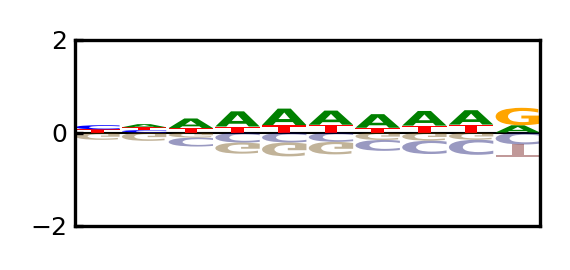

In [11]:
df_logo = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[0]).T, columns=['A', 'C', 'G', 'T'])
df_logo = df_logo.sub(df_logo.mean(axis=1), axis=0)  # Center each row

fig, ax = plt.subplots(figsize=(2, 1), dpi=300, sharey=True)

ShowLogo(ax, df_logo)
ax.set_xticks([])
# ax.set_yticks([-.3, 0, .3])
ax.set_ylim(-2, 2)
ax.tick_params(axis='both', which='both', labelsize=6, direction='in', length=2, pad=2)

plt.tight_layout()
plt.savefig("../figures/Logo_SL17.svg")
plt.show()

In [ ]:
stop

NameError: name 'stop' is not defined

In [ ]:
def getEnergies(seqs):
    seqs_arr = np.array([dna_one_hot(seq) for seq in seqs])
    seqs_arr_tensor = torch.tensor(seqs_arr, dtype=torch.float32).to(device)    
    energies = model.energy(seqs_arr_tensor).cpu().squeeze(1).detach().numpy()
    return energies

def predict(seqs):
    seqs_arr = np.array([dna_one_hot(seq) for seq in seqs])
    seqs_arr_tensor = torch.tensor(seqs_arr, dtype=torch.float32).to(device)    
    expressions = model.energy2expression(model.energy(seqs_arr_tensor)).cpu().squeeze(1).detach().numpy()
    return expressions/np.log(10)

def correctionTerm():
    df_weight = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[0]).T, columns=['A', 'C', 'G', 'T'])
    return df_weight.mean(axis=1).sum()

In [ ]:
df = pd.read_pickle("../tables/SL17.pkl")
df['Energy'] = getEnergies(df.index) - correctionTerm()
df['LogGFP_pred'] = predict(df.index)
df

,rep1,rep2,LogGFP,Energy,LogGFP_pred
TCTTGATAGGTTGCAAC,2.632971,2.482732,2.557851,-0.780039,2.196667
CACTTGAAGCGAGTTCG,2.069150,2.055713,2.062431,-1.103925,1.998326
TCACATTTCAATGACTT,1.206943,1.081012,1.143977,0.175670,2.667282
ACAGATAGCGTGTTAAT,2.189826,1.895392,2.042609,-0.699493,2.243753
CGTCTAGTCGTAAATCT,2.013793,2.265564,2.139678,-0.999159,2.063872
...,...,...,...,...,...
GAAAGATACGTGGTCTA,2.266853,2.265564,2.266209,-1.320122,1.859783
GTCTGATTACGGCATTT,2.266853,2.106661,2.186757,-1.104961,1.997672
CAGAAAAGGGCGTTATC,1.610837,1.724472,1.667655,-1.681529,1.621242
TATGCCGAGGCAGCTTC,2.239267,2.265564,2.252415,-0.414121,2.401310


In [ ]:
# 1. 讀全部 SL17 序列並算能量 + 模型預測
df = pd.read_pickle("../tables/SL17.pkl").copy()
df['Energy']      = getEnergies(df.index) - correctionTerm()
df['LogGFP_pred'] = predict(df.index)

# 2. 用 Energy 由強到弱排序
metric = 'Energy'   # 想改用實測就換成 'LogGFP'
df_sorted = df.sort_values(metric, ascending=False)
df_sorted.index.name = 'Sequence'
df_sorted = df_sorted.reset_index()
n = len(df_sorted)

# 3. 取 5 個區間中心 (強→弱)：rank 10/30/50/70/90 %
#    若想要 B 方案(ㄇ100/75/50/25/0%)，改成 [0.0, 0.25, 0.5, 0.75, 1.0]
targets = [0.125, 0.375, 0.625, 0.875]
picks = [df_sorted.iloc[int(round(t*(n-1)))] for t in targets]

df_picks = pd.DataFrame(picks).reset_index(drop=True)
df_picks['Strength_level'] = ['~87.5% (最強)', '~62.5%', '~37.5%', '~12.5% (最弱)']
df_picks[['Strength_level', 'Sequence', 'LogGFP', 'LogGFP_pred', 'Energy']]


,Strength_level,Sequence,LogGFP,LogGFP_pred,Energy
0,~87.5% (最強),TACGTACTTTGCATCGA,2.636027,2.537314,-0.137434
1,~62.5%,AAATATCAGGTTGCCAC,2.580168,2.242728,-0.701267
2,~37.5%,TAATTCAACTAGGTCCA,1.798690,1.995224,-1.108839
3,~12.5% (最弱),CACTATTGCTATGATCC,1.790930,1.667153,-1.612707


In [ ]:
def score_sequences(seqs):
    """輸入 17bp spacer 序列，回傳能量、預測 GFP；若序列在資料庫中，附上實測 LogGFP。"""
    if isinstance(seqs, str):
        seqs = [seqs]

    # 模型推算
    df_out = pd.DataFrame({'Sequence': seqs})
    df_out['Energy']      = getEnergies(seqs) - correctionTerm()
    df_out['LogGFP_pred'] = predict(seqs)
    df_out['GFP_pred']    = 10 ** df_out['LogGFP_pred']

    # 查資料庫實測值（不在庫的會是 NaN）
    df_db = pd.read_pickle("../tables/SL17.pkl")
    df_out['LogGFP_meas'] = df_out['Sequence'].map(df_db['LogGFP'])
    df_out['in_database'] = df_out['LogGFP_meas'].notna()

    return df_out[['Sequence', 'in_database', 'LogGFP_meas', 'LogGFP_pred', 'GFP_pred', 'Energy']]

# === 使用範例 ===
# score_sequences(["AAATATCAGGTTGCCAC", "AAATATCAGGTTGCCTG", "AAATATCAGGTTGCCGG", "AAATATCAGGTTGCCTT","AAATATCAGGTTGCCGT"])
score_sequences(["TACGTACTTTGCATCGA", "AAATATCAGGTTGCCAC","TAATTCAACTAGGTCTG" ,"TAATTCAACTAGGTCCA", "CACTATTGCTATGATCC"])
# score_sequences("GGGGGGGGGGGGGGGGG")
# 多條：
# score_sequences(["ATGGGATATATGACCAG", "CCTTAGTAGGCGATATC"])


,Sequence,in_database,LogGFP_meas,LogGFP_pred,GFP_pred,Energy
0,TACGTACTTTGCATCGA,True,2.636027,2.537314,344.599304,-0.137434
1,AAATATCAGGTTGCCAC,True,2.580168,2.242728,174.874908,-0.701267
2,TAATTCAACTAGGTCTG,False,NaN,2.770958,590.143921,0.493480
3,TAATTCAACTAGGTCCA,True,1.798690,1.995224,98.906204,-1.108839
4,CACTATTGCTATGATCC,True,1.790930,1.667153,46.467934,-1.612707
